# =======================================
# HEART DISEASES DATASET EXPLORATORY DATA ANALYSIS
# =======================================

In [16]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder


DATASET: 
Kaggle Heart Diseases Dataset

ABOUT: 
The Kaggle Heart Disease dataset contains patient data with features like age, sex, blood pressure, and cholesterol. The target is a binary indicator of heart disease, making it ideal for exploring distributions, correlations, and classification tasks.

QUESTIONS TO ANSWER:
1. What factors are most strongly associated with heart disease?    
2. What sex in more common to have heart disease
3. How does age affect heart disease risk?
4. Is the dataset linearly separable, or are some disease cases inherently ambiguous?


In [17]:
# Load data
df = pd.read_csv('heart_disease_dataset.csv')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

### =============================================
### 2. DATA OVERVIEW
### =============================================

In [18]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [19]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [20]:
df.shape

(918, 12)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


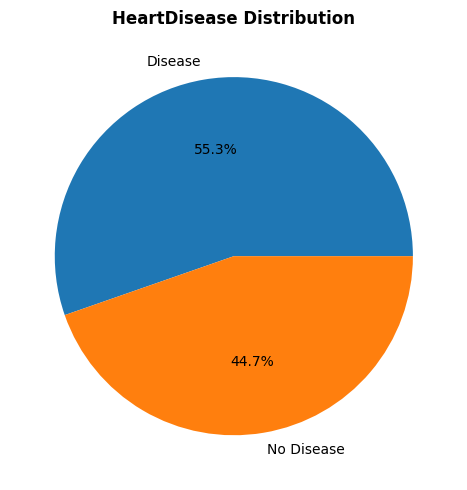

In [22]:
counts = df['HeartDisease'].value_counts()

label_map = {0: "No Disease", 1: "Disease"}
labels = [label_map[i] for i in counts.index]

plt.figure(figsize=(5, 5))
plt.pie(counts, labels=labels, autopct='%1.1f%%')

plt.title("HeartDisease Distribution", weight='bold')
plt.tight_layout()
plt.show()

### =============================================
### 3. Data Cleaning
### =============================================

In [23]:
missing_values = df.isnull().sum()
display(missing_values)


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [24]:
columns = df.columns.to_list()

object_cols = df.select_dtypes(include='object').columns.to_list()
object_cols.remove('ST_Slope') #We will one-hot encode this
object_cols

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina']

In [25]:
names = ['Sex','ChestPainType','RestingECG','ExerciseAngina']
for n, o in zip(names, object_cols):    
    ChestPainType_unique = df[o].unique()
    print(f"|{n}| unique values: {ChestPainType_unique}")

|Sex| unique values: ['M' 'F']
|ChestPainType| unique values: ['ATA' 'NAP' 'ASY' 'TA']
|RestingECG| unique values: ['Normal' 'ST' 'LVH']
|ExerciseAngina| unique values: ['N' 'Y']


In [26]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [27]:
sex_map = {'M': 1, 'F': 0}
chestPainType_map = {'ASY': 0, 'NAP': 1, 'ATA':2, 'TA': 3}
restingECG_map = {'Normal': 0, 'ST': 1, 'LVH':2}
exerciseAngina_map = {'N': 0, 'Y': 1}

maps = [sex_map, chestPainType_map, restingECG_map, exerciseAngina_map]

for m, col in zip(maps, object_cols):
    df[col] = df[col].map(m)

In [28]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,2,140,289,0,0,172,0,0.0,Up,0
1,49,0,1,160,180,0,0,156,0,1.0,Flat,1
2,37,1,2,130,283,0,1,98,0,0.0,Up,0
3,48,0,0,138,214,0,0,108,1,1.5,Flat,1
4,54,1,1,150,195,0,0,122,0,0.0,Up,0


In [29]:
encoder = OneHotEncoder(sparse_output=False)
encoded_stSlope = encoder.fit_transform(df[['ST_Slope']])

encoded_stSlope = pd.DataFrame(encoded_stSlope, columns=encoder.get_feature_names_out(['ST_Slope']))
df = df.drop('ST_Slope', axis=1).join(encoded_stSlope)


In [30]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,2,140,289,0,0,172,0,0.0,0,0.0,0.0,1.0
1,49,0,1,160,180,0,0,156,0,1.0,1,0.0,1.0,0.0
2,37,1,2,130,283,0,1,98,0,0.0,0,0.0,0.0,1.0
3,48,0,0,138,214,0,0,108,1,1.5,1,0.0,1.0,0.0
4,54,1,1,150,195,0,0,122,0,0.0,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,3,110,264,0,0,132,0,1.2,1,0.0,1.0,0.0
914,68,1,0,144,193,1,0,141,0,3.4,1,0.0,1.0,0.0
915,57,1,0,130,131,0,0,115,1,1.2,1,0.0,1.0,0.0
916,57,0,2,130,236,0,2,174,0,0.0,1,0.0,1.0,0.0
